## Add available geomorphological information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-1st.csv', encoding=enc)
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [5]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,478.8,38293.0,86.8,46.44911,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,22.142500,32.180000,12.105000,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,1.026141,4.464013,54.796496,202,0,0
1,21.94079,40.97703,2023-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,985.8,24924.0,28.0,46.48134,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,11.679091,17.064545,6.293636,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,7.549537,31.277387,172.360332,40,0,0
2,22.89198,40.65603,2023-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,9.8,49674.0,5319.1,46.65786,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,19.870000,27.870000,11.870000,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,8.539829,24.316921,129.586469,161,0,0
3,23.98253,40.91510,2023-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,411.8,7169.0,22.3,47.42581,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14.947500,20.875000,9.020000,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,12.292893,36.676132,73.469888,186,0,0
4,23.69108,40.49593,2023-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,747.0,16994.0,24.5,46.91682,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,13.673750,18.335000,9.012500,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,13.509865,88.392827,161.783456,54,0,0


In [6]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.05105,40.31951,2802.421393,4354.991527,14,231.417467,276.517281,188.889456,0.0,3.998248
1,24.05105,40.35544,1849.716366,697.392287,26,127.358018,145.408143,163.763939,0.0,2.006094
2,24.09803,40.31951,3388.512883,5473.471255,13,192.256866,239.376381,181.658242,0.0,3.609011
3,24.30947,40.15781,2116.919637,4867.646762,44,285.956649,945.458571,240.592577,0.0,3.887520
4,21.83449,40.75699,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.0,1.059672


In [7]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [8]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 9.045170238510034


In [9]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [10]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [11]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [12]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.48398,40.64468,2023-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,478.8,38293.0,86.8,46.44911,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,22.142500,32.180000,12.105000,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,1.026141,4.464013,54.796496,202,0,0,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407
1,21.94079,40.97703,2023-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,985.8,24924.0,28.0,46.48134,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,11.679091,17.064545,6.293636,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,7.549537,31.277387,172.360332,40,0,0,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000
2,22.89198,40.65603,2023-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,9.8,49674.0,5319.1,46.65786,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,19.870000,27.870000,11.870000,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,8.539829,24.316921,129.586469,161,0,0,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007
3,23.98253,40.91510,2023-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,411.8,7169.0,22.3,47.42581,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14.947500,20.875000,9.020000,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,12.292893,36.676132,73.469888,186,0,0,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232
4,23.69108,40.49593,2023-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,747.0,16994.0,24.5,46.91682,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,13.673750,18.335000,9.012500,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,13.509865,88.392827,161.783456,54,0,0,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661


<AxesSubplot:>

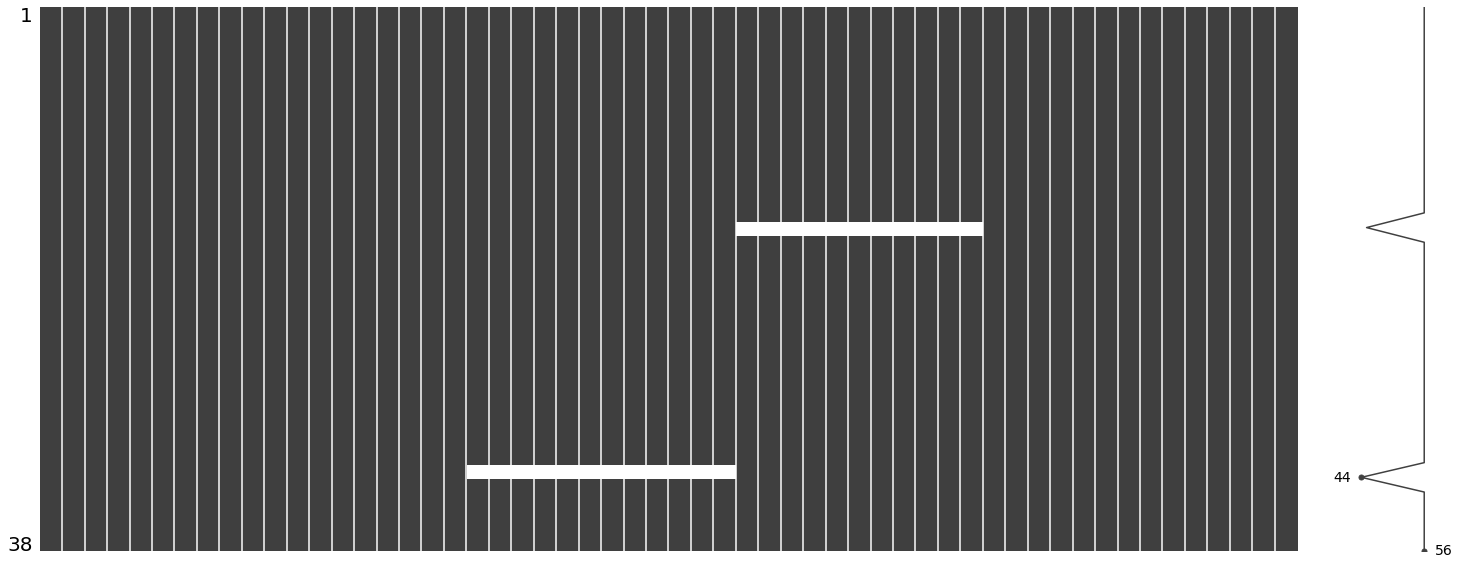

In [13]:
missingno.matrix(dataset)

In [14]:
cols = dataset.columns

In [15]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [16]:
len(cols)

56

In [17]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [18]:
len(rearranged)

56

In [19]:
dataset = dataset[rearranged]

In [20]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-1st.csv", encoding = enc, index = False)